# Intuición del Gradient Descent

## Bootcamp Python - PY4
## Módulo 3: Deep Learning y NLP

En el Notebook 1 tuvimos un primer contacto con la idea de
gradient descent: movimos a mano un solo peso de una neurona, y vimos si el
loss subía o bajaba. Acá vamos a profundizar esa intuición con un ejemplo
mucho más concreto y visual.

Este notebook está inspirado en la manera en que el libro *"Deep Learning
for Coders"* (fastai), en su capítulo 4, explica el gradient descent: en vez
de arrancar directamente con una red neuronal, arrancan con un problema
mucho más simple (ajustar una curva a un puñado de puntos), donde se puede
ver clarísimo cada paso del proceso.

### Lo que vamos a hacer:

1. Repasar el proceso de gradient descent como una receta de 5 pasos.
2. Ver la intuición geométrica con la función más simple posible: `x²`.
3. Ver cómo TensorFlow calcula derivadas automáticamente, sin que nosotros
   tengamos que hacer cálculo a mano.
4. Aplicar la receta completa a un problema real (aunque chico): ajustar una
   curva a un conjunto de puntos, igual que en el libro de fastai.
5. Explorar qué pasa cuando el learning rate es muy chico, muy grande, o
   justo.
6. Conectar todo esto de vuelta con lo que hace Keras cuando llamamos a
   `model.fit()`.


## 0. Preparando el entorno


In [1]:
# Importamos las librerias que vamos a necesitar
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Fijamos semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)


## 1. Gradient descent: una receta de 5 pasos

Cualquier proceso de entrenamiento por gradient descent, sin importar qué
tan grande o chico sea el modelo, sigue siempre la misma receta:

1. **Inicializar**: arrancamos con parámetros (pesos) al azar. No saben nada
   todavía.
2. **Predecir**: usamos los parámetros actuales para hacer una predicción
   (esto es el forward pass que vimos en el Notebook 1).
3. **Calcular el loss**: medimos qué tan lejos está esa predicción del valor
   real.
4. **Calcular el gradiente**: para cada parámetro, calculamos en qué
   dirección y con qué magnitud deberíamos moverlo para que el loss baje.
   Esto es lo que en el Notebook 1 hicimos a mano, nudgeando un peso de a
   uno; acá vamos a dejar que TensorFlow lo calcule automáticamente con
   cálculo diferencial (esto se llama **backpropagation**).
5. **Actualizar (step)**: movemos cada parámetro un poquito en la dirección
   que el gradiente indicó, usando un **learning rate** que controla qué tan
   grande es ese paso.

Después del paso 5, se vuelve al paso 2 y se repite todo el proceso, una y
otra vez, hasta que el loss deje de mejorar (o hasta que decidamos parar).

```
inicializar -> predecir -> loss -> gradiente -> actualizar -> (repetir desde predecir)
```

Vamos a ver esta receta en acción con un ejemplo mucho más simple que una
red neuronal completa, para poder observar cada paso con claridad.


## 2. La intuición geométrica: la función x²

Antes de ajustar nada, miremos la función más simple posible:
`f(x) = x²`. Vamos a pensarla como si fuera un loss: el eje x representa un
parámetro cualquiera, y el eje y representa qué tan "mal" estamos (el loss)
para cada valor de ese parámetro.


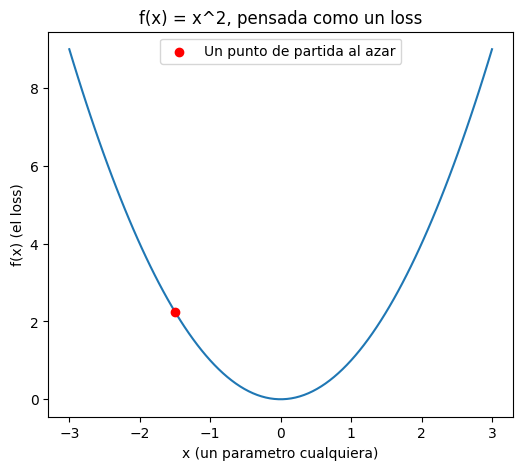

In [2]:
# Graficamos la funcion f(x) = x^2
x_vals = np.linspace(-3, 3, 100)
y_vals = x_vals ** 2

plt.figure(figsize=(6, 5))
plt.plot(x_vals, y_vals)
plt.scatter([-1.5], [(-1.5) ** 2], color="red", zorder=5, label="Un punto de partida al azar")
plt.title("f(x) = x^2, pensada como un loss")
plt.xlabel("x (un parametro cualquiera)")
plt.ylabel("f(x) (el loss)")
plt.legend()
plt.show()


Mirá el punto rojo, en `x = -1.5`. Si estuviéramos parados ahí, y
quisiéramos bajar el loss (movernos hacia el punto más bajo de la curva,
en `x = 0`), ¿para qué lado deberíamos movernos?

La pendiente de la curva en ese punto nos lo dice: como la curva viene
bajando de izquierda a derecha en ese tramo, la pendiente ahí es negativa, lo
que significa que **aumentar x** hace bajar el loss. Esa pendiente es
justamente la **derivada** de la función en ese punto, y es exactamente lo
que un gradiente representa: la dirección de mayor crecimiento del loss. Nos
movemos en la dirección contraria al gradiente, porque queremos que el loss
baje, no que suba.

Con una sola variable, esto se puede calcular a mano con las reglas de
derivación que quizás ya conozcas (la derivada de `x²` es `2x`). Pero en una
red neuronal real hay miles o millones de parámetros: calcular todas esas
derivadas a mano es imposible. Ahí es donde entra TensorFlow.


## 3. TensorFlow calcula derivadas por nosotros

TensorFlow tiene una herramienta llamada `GradientTape` ("cinta de
gradientes"): registra las operaciones matemáticas que hacemos dentro de su
bloque `with`, y después puede calcular automáticamente la derivada de
cualquier resultado con respecto a cualquier variable que haya participado
en el cálculo.

Vamos a comprobarlo con nuestra función `x²`. Sabemos que la derivada de
`x²` es `2x`, así que en `x = 3` esperamos que el gradiente sea `6`.


In [3]:
# Definimos x como una variable de TensorFlow (no un numero fijo)
x = tf.Variable(3.0)

# Registramos las operaciones dentro del GradientTape
with tf.GradientTape() as tape:
    y = x ** 2

# Le pedimos a TensorFlow que calcule dy/dx
gradiente = tape.gradient(y, x)

print("x:", x.numpy())
print("y = x^2:", y.numpy())
print("gradiente (dy/dx):", gradiente.numpy())


x: 3.0
y = x^2: 9.0
gradiente (dy/dx): 6.0


TensorFlow calculó el gradiente sin que nosotros escribiéramos
ninguna fórmula de derivación. Esto es exactamente lo que discutimos en el
Notebook 1: en vez de nosotros probar a mano si mover un peso hacia arriba o
hacia abajo mejora el loss, `GradientTape` usa cálculo diferencial para
calcular la respuesta exacta, de una sola vez.

En una red neuronal, este mismo mecanismo (llamado **backpropagation**) se
aplica a todos los pesos de todas las capas al mismo tiempo, usando la regla
de la cadena para propagar el cálculo desde la capa de salida hacia atrás,
hasta la capa de entrada.


## 4. El ejemplo de la montaña rusa

Vamos a aplicar la receta completa de 5 pasos a un problema real, aunque
chico: tenemos la velocidad de una montaña rusa medida en distintos momentos
del tiempo, y queremos encontrar la curva que mejor describe esa velocidad a
lo largo del tiempo.

### Generando los datos

Simulamos 20 mediciones de velocidad a lo largo del tiempo, con algo de
ruido, siguiendo una forma cuadrática (como la que tendría una montaña rusa
que frena, se detiene, y vuelve a acelerar).


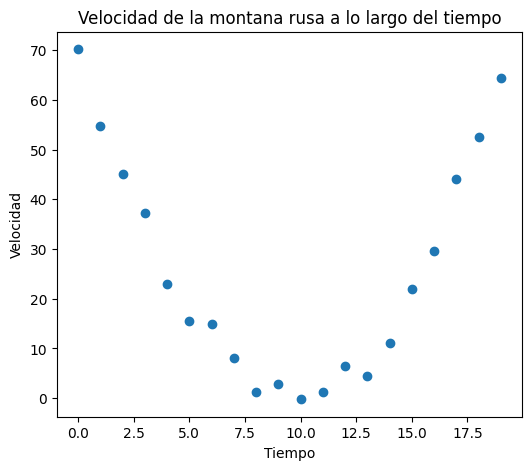

In [4]:
# Generamos datos sinteticos de velocidad a lo largo del tiempo
tiempo = tf.range(0, 20, dtype=tf.float32)
velocidad = np.random.randn(20) * 3 + 0.75 * (tiempo.numpy() - 9.5) ** 2 + 1
velocidad = tf.constant(velocidad, dtype=tf.float32)

plt.figure(figsize=(6, 5))
plt.scatter(tiempo, velocidad)
plt.title("Velocidad de la montana rusa a lo largo del tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad")
plt.show()


### Definiendo el modelo y el loss

Vamos a asumir que la velocidad sigue una curva cuadrática:

`velocidad = a * tiempo² + b * tiempo + c`

Los parámetros `a`, `b` y `c` son justamente lo que queremos encontrar con
gradient descent. Como loss, usamos el error cuadrático medio (MSE), la
misma idea que usamos en clase con `binary_crossentropy`, pero para un
problema de regresión en vez de clasificación.


In [5]:
# Definimos la funcion que representa nuestro modelo (una parabola)
def f(t, params):
    a, b, c = params[0], params[1], params[2]
    return a * (t ** 2) + b * t + c

# Definimos el error cuadratico medio como funcion de loss
def mse(predicciones, objetivo):
    return tf.reduce_mean((predicciones - objetivo) ** 2)


### Paso 1: inicializar

Arrancamos con `a`, `b` y `c` al azar. Como todavía no aprendieron nada, la
curva que producen no se va a parecer en nada a nuestros datos.


In [6]:
# Inicializamos los tres parametros al azar
# Fijamos este seed en particular porque nos da un punto de partida
# bien alejado de los datos reales, ideal para ver el efecto del entrenamiento
tf.random.set_seed(6)
params = tf.Variable(tf.random.normal([3]))
params_iniciales = tf.Variable(params)  # guardamos una copia para mas adelante

print("Parametros iniciales (a, b, c):", params.numpy())


Parametros iniciales (a, b, c): [-0.30706483 -0.94067    -0.08064285]


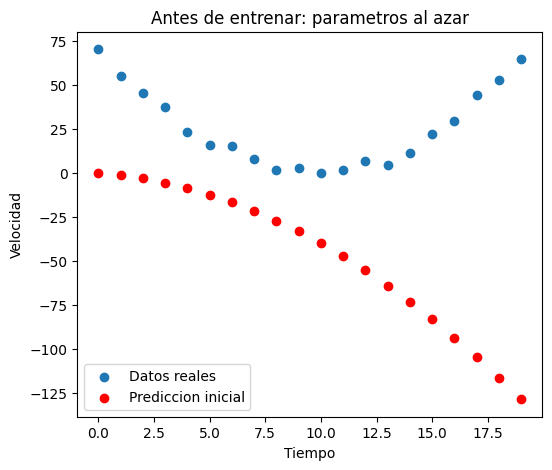

In [7]:
# Graficamos que tan mal predice el modelo con parametros al azar
predicciones_iniciales = f(tiempo, params)

plt.figure(figsize=(6, 5))
plt.scatter(tiempo, velocidad, label="Datos reales")
plt.scatter(tiempo, predicciones_iniciales.numpy(), color="red", label="Prediccion inicial")
plt.title("Antes de entrenar: parametros al azar")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad")
plt.legend()
plt.show()


### Pasos 2, 3 y 4: predecir, calcular el loss, y calcular el gradiente

Ahora damos un solo paso de la receta: predecimos, medimos el loss, y le
pedimos a `GradientTape` el gradiente de ese loss con respecto a cada uno de
los tres parámetros.


In [8]:
# Un solo paso: predecir, calcular el loss, y calcular el gradiente
with tf.GradientTape() as tape:
    predicciones = f(tiempo, params)
    loss = mse(predicciones, velocidad)

gradientes = tape.gradient(loss, params)

print("Loss actual:", loss.numpy())
print("Gradiente (uno por cada parametro a, b, c):", gradientes.numpy())


Loss actual: 7606.487
Gradiente (uno por cada parametro a, b, c): [-27902.477    -1805.5671    -144.72623]


### Paso 5: actualizar los parámetros

Movemos cada parámetro en la dirección contraria a su gradiente (para que el
loss baje), multiplicado por el learning rate. Con `assign_sub`, le decimos
a TensorFlow "restale esto a la variable actual".


In [9]:
# Definimos el learning rate
lr = 1e-5

# Actualizamos los parametros: nos movemos en direccion contraria al gradiente
params.assign_sub(lr * gradientes)

print("Parametros despues de un paso:", params.numpy())

# Verificamos que el loss haya bajado
nuevas_predicciones = f(tiempo, params)
nuevo_loss = mse(nuevas_predicciones, velocidad)
print("Loss antes de este paso:", loss.numpy())
print("Loss despues de este paso:", nuevo_loss.numpy())


Parametros despues de un paso: [-0.02804008 -0.92261434 -0.07919559]
Loss antes de este paso: 7606.487
Loss despues de este paso: 1996.835


El loss bajó con un solo paso. Ahora, la receta dice que hay que
volver al paso 2 y repetir. Vamos a armar una función que hace los 5 pasos
juntos, y la vamos a llamar muchas veces seguidas.


In [10]:
# Funcion que aplica un paso completo de gradient descent
def aplicar_paso(params, lr):
    with tf.GradientTape() as tape:
        predicciones = f(tiempo, params)
        loss = mse(predicciones, velocidad)
    gradientes = tape.gradient(loss, params)
    params.assign_sub(lr * gradientes)
    return loss.numpy()


### Visualizando los primeros pasos

Antes de entrenar muchos pasos seguidos, veamos qué pasa en los primeros 4
pasos, arrancando de nuevo desde los parámetros iniciales al azar. Esto
suele ser donde se nota el cambio más dramático.


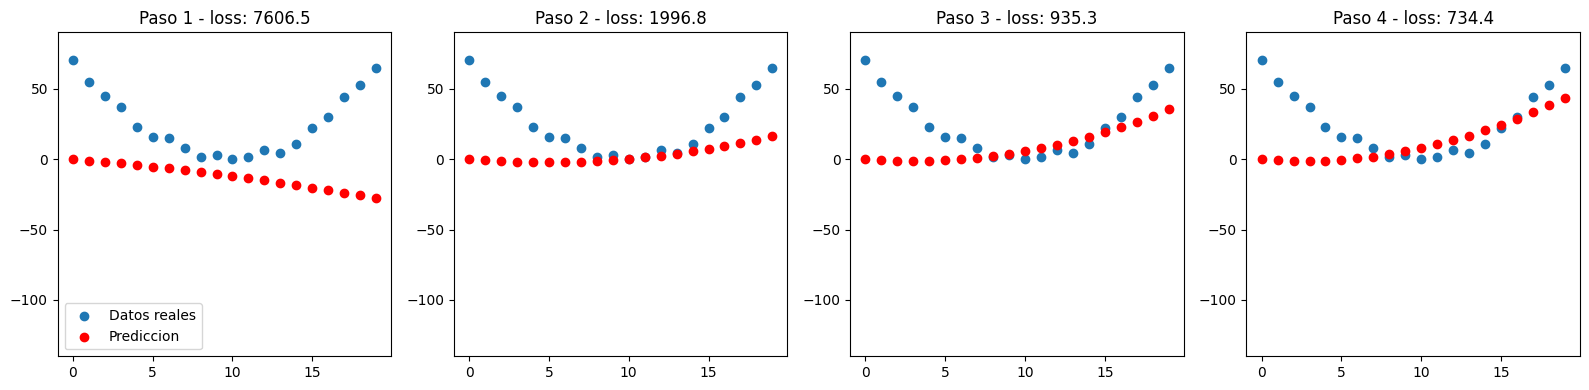

In [11]:
# Reiniciamos los parametros a su valor inicial
params_demo = tf.Variable(params_iniciales)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, ax in enumerate(axes):
    loss_actual = aplicar_paso(params_demo, lr)
    predicciones_actuales = f(tiempo, params_demo)

    ax.scatter(tiempo, velocidad, label="Datos reales")
    ax.scatter(tiempo, predicciones_actuales.numpy(), color="red", label="Prediccion")
    ax.set_title(f"Paso {i + 1} - loss: {loss_actual:.1f}")
    ax.set_ylim(-140, 90)

axes[0].legend()
plt.tight_layout()
plt.show()


Fijate cómo, en apenas 4 pasos, la curva roja ya empieza a parecerse
a la forma de los datos reales. Cada paso mueve un poco los parámetros en la
dirección que reduce el loss.

### Entrenando muchos pasos y graficando el loss

Ahora entrenemos muchos más pasos seguidos (arrancando de nuevo desde cero),
y grafiquemos cómo evoluciona el loss a lo largo de las iteraciones.


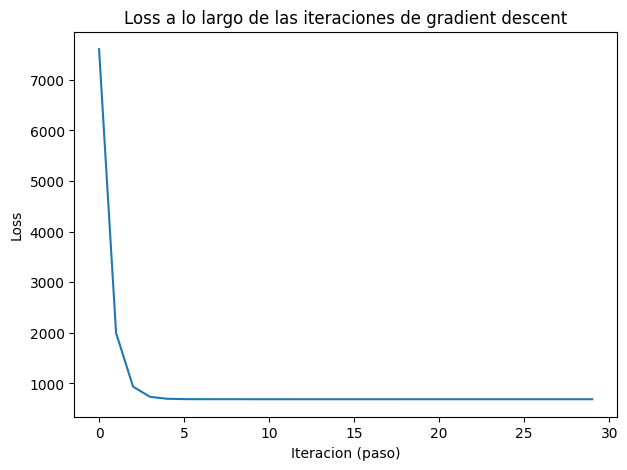

Loss inicial: 7606.487
Loss final: 687.3663
Parametros finales (a, b, c): [ 0.18649489 -0.9045432  -0.07183606]


In [12]:
# Reiniciamos los parametros y entrenamos 30 pasos, guardando el loss de cada uno
params_entrenamiento = tf.Variable(params_iniciales)

historial_loss = []
for i in range(30):
    loss_actual = aplicar_paso(params_entrenamiento, lr)
    historial_loss.append(loss_actual)

plt.figure(figsize=(7, 5))
plt.plot(historial_loss)
plt.title("Loss a lo largo de las iteraciones de gradient descent")
plt.xlabel("Iteracion (paso)")
plt.ylabel("Loss")
plt.show()

print("Loss inicial:", historial_loss[0])
print("Loss final:", historial_loss[-1])
print("Parametros finales (a, b, c):", params_entrenamiento.numpy())


Vas a notar que el loss baja muy rápido al principio, y después se
queda prácticamente estancado. Esto no es un error: es una limitación real
del gradient descent "puro" (con un learning rate fijo, igual para los tres
parámetros) cuando las variables tienen escalas muy distintas (`tiempo` va
de 0 a 19, pero `tiempo²` llega hasta 361). Vamos a retomar esta observación
más adelante, porque conecta directamente con por qué en clase siempre
usamos el optimizador `adam` en vez de gradient descent simple.


## 5. El rol del learning rate

El learning rate controla qué tan grande es cada paso. Elegirlo mal puede
arruinar el entrenamiento de dos formas distintas:

- **Muy chico**: el entrenamiento avanza, pero extremadamente lento.
- **Muy grande**: en vez de acercarse al mínimo, los pasos son tan grandes
  que el modelo se aleja cada vez más, y el loss explota en vez de bajar.

Vamos a comparar tres learning rates distintos sobre el mismo problema de la
montaña rusa, todos arrancando desde los mismos parámetros iniciales.


In [13]:
# Funcion para entrenar N pasos con un learning rate dado, siempre desde el mismo punto de partida
def entrenar(lr, pasos=15):
    params_lr = tf.Variable(params_iniciales)
    historial = []
    for i in range(pasos):
        with tf.GradientTape() as tape:
            predicciones = f(tiempo, params_lr)
            loss = mse(predicciones, velocidad)
        gradientes = tape.gradient(loss, params_lr)
        params_lr.assign_sub(lr * gradientes)
        historial.append(loss.numpy())
    return historial

# Probamos tres learning rates distintos
historial_chico = entrenar(lr=1e-7)
historial_bueno = entrenar(lr=1e-5)
historial_grande = entrenar(lr=1e-4)

print("Learning rate muy chico (1e-7):", [round(float(l), 1) for l in historial_chico])
print()
print("Learning rate razonable (1e-5):", [round(float(l), 1) for l in historial_bueno])
print()
print("Learning rate muy grande (1e-4):", [f"{float(l):.2e}" for l in historial_grande])


Learning rate muy chico (1e-7): [7606.5, 7528.5, 7451.4, 7375.2, 7299.9, 7225.4, 7151.7, 7078.9, 7006.8, 6935.6, 6865.2, 6795.6, 6726.8, 6658.7, 6591.5]

Learning rate razonable (1e-5): [7606.5, 1996.8, 935.3, 734.4, 696.4, 689.2, 687.8, 687.6, 687.5, 687.5, 687.5, 687.5, 687.5, 687.5, 687.5]

Learning rate muy grande (1e-4): ['7.61e+03', '1.50e+05', '3.24e+06', '6.99e+07', '1.51e+09', '3.27e+10', '7.07e+11', '1.53e+13', '3.31e+14', '7.15e+15', '1.55e+17', '3.34e+18', '7.22e+19', '1.56e+21', '3.38e+22']


Con el learning rate muy grande, vas a ver números gigantes o
directamente `inf` (infinito): el entrenamiento **diverge**, en vez de
mejorar empeora sin control. Grafiquemos los dos casos que sí se pueden
comparar en la misma escala (chico y razonable), para ver la diferencia de
velocidad de convergencia.


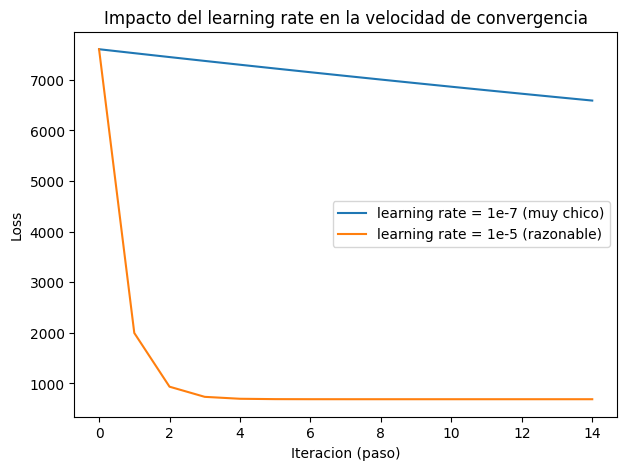

In [14]:
# Graficamos el learning rate chico vs el razonable, en la misma escala
plt.figure(figsize=(7, 5))
plt.plot(historial_chico, label="learning rate = 1e-7 (muy chico)")
plt.plot(historial_bueno, label="learning rate = 1e-5 (razonable)")
plt.title("Impacto del learning rate en la velocidad de convergencia")
plt.xlabel("Iteracion (paso)")
plt.ylabel("Loss")
plt.legend()
plt.show()


Con un learning rate demasiado chico, el modelo sí mejora, pero
haría falta entrenar muchísimos más pasos para llegar a un buen resultado:
en la práctica, es tiempo (y cómputo) desperdiciado. Con un learning rate
demasiado grande, ni siquiera llegamos a mejorar: el entrenamiento se rompe
directamente. Encontrar un buen learning rate es, en la práctica, uno de los
ajustes más importantes (y a veces más delicados) al entrenar una red
neuronal.


## 6. De este ejemplo a una red neuronal real

Todo lo que hicimos en este notebook es, en esencia, exactamente lo que
Keras hace por nosotros cada vez que llamamos a `model.fit()`:

| En este notebook | En Keras |
|---|---|
| `params = tf.Variable(...)` | Los pesos de cada capa `Dense`, inicializados automáticamente |
| `f(tiempo, params)` | El forward pass a través de todas las capas |
| `mse(predicciones, velocidad)` | La función de loss (`binary_crossentropy`, `mse`, etc.) |
| `tape.gradient(loss, params)` | Backpropagation, calculado automáticamente |
| `params.assign_sub(lr * gradientes)` | Lo que hace el optimizador en cada paso |
| Nuestro loop de `for` manual | Lo que ocurre "adentro" de `model.fit()` |

La diferencia principal es de escala: en vez de 3 parámetros, una red
neuronal tiene miles o millones, organizados en capas. Y en vez de un
learning rate fijo e igual para todos los parámetros (lo que usamos acá,
`assign_sub(lr * gradientes)`), Keras usa por defecto el optimizador
**Adam**, que ajusta automáticamente el tamaño del paso para cada parámetro
por separado.

Esto conecta directamente con algo que observamos en la sección 4: nuestro
loss se quedó estancado alrededor de 678, porque `a` (que multiplica a
`tiempo²`) necesitaría un learning rate distinto que `c` (que es
prácticamente un número suelto) para converger bien. Adam resuelve
exactamente este tipo de problema, adaptando el paso de cada parámetro según
su propio historial de gradientes. Es una de las razones por las que, en
todos nuestros modelos de clase, usamos `optimizer="adam"` en vez de
gradient descent simple.


## Cierre

En este notebook vimos, de la forma más concreta posible, qué hay detrás de
la palabra "entrenamiento" en Deep Learning:

- Un ciclo de 5 pasos que se repite una y otra vez: inicializar, predecir,
  calcular el loss, calcular el gradiente, y actualizar.
- Que el gradiente es, geométricamente, la pendiente de la función de loss:
  nos dice para qué lado movernos.
- Que TensorFlow puede calcular esos gradientes automáticamente con
  `GradientTape`, sin que nosotros hagamos cálculo a mano, sin importar
  cuántos parámetros tenga el modelo.
- Que el learning rate es un parámetro delicado: muy chico desperdicia
  tiempo, muy grande rompe el entrenamiento.

### Para pensar

- ¿Por qué creés que el loss del ejemplo de la montaña rusa mejoró tan
  rápido al principio, y después se estancó?
- Si tuvieras que explicarle a alguien que recién empieza qué es
  "entrenar una red neuronal", usando el ejemplo de este notebook, ¿qué le
  dirías con tus propias palabras?
